C:\Users\till_\AppData\Local\Temp\ipykernel_12868\1736259516.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='3y')['Close']
[*********************100%***********************]  2 of 2 completed
C:\Users\till_\AppData\Local\Temp\ipykernel_12868\1736259516.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


Value at Risk (95% Konfidenz): -2.89%
Maximaler erwarteter Verlust bei 10.000€: 289.43€


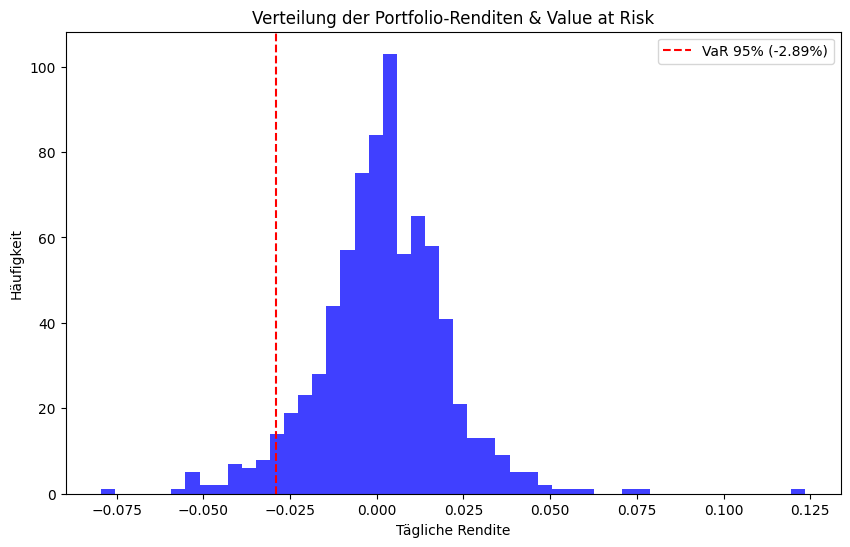

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ['DB', 'CBK.DE']

data = yf.download(tickers, period='3y')['Close']
returns = data.pct_change().dropna()

weights = np.array([0.5, 0.5])
initial_investment = 10000

portfolio_returns = returns.dot(weights)

var_95 = np.percentile(portfolio_returns, 5)
potential_loss = initial_investment * var_95

print(f"Value at Risk (95% Konfidenz): {var_95:.2%}")
print(f"Maximaler erwarteter Verlust bei 10.000€: {abs(potential_loss):.2f}€")

plt.figure(figsize=(10,6))
plt.hist(portfolio_returns, bins=50, alpha=0.75, color='blue')
plt.axvline(var_95, color='red', linestyle='--', label=f'VaR 95% ({var_95:.2%})')
plt.title('Verteilung der Portfolio-Renditen & Value at Risk')
plt.xlabel('Tägliche Rendite')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()